# The bulk photovoltaic effect: a solar cell with no junction

A silicon solar cell needs a junction. Two doped regions build an internal field, the field
separates the electron from the hole, and the voltage you can get out is bounded by the
built-in potential, which is bounded by the gap.

A crystal with no inversion centre does not need any of that. Illuminate it uniformly and it
carries a **direct current** all by itself, with no junction, no interface and no built-in
field. The photovoltage is not bounded by the gap and has been measured in the kilovolts.
The intrinsic part of the effect is the **shift current**, and the name says the mechanism:
the photoexcited electron is not born where the hole is left behind. It appears displaced,
by the distance between the valence and conduction charge centres, and that displacement
per absorbed photon is the current.

It is a second-order response to the field,

$$ J^a \;=\; 2\,\sigma^{abc}(0;\omega,-\omega)\,\mathcal{E}_b(\omega)\,\mathcal{E}_c(-\omega), $$

and $\sigma^{abc}$ is a polar rank-3 tensor, so **inversion symmetry kills it entirely**.
That single fact is most of what this notebook shows: zincblende AlAs has one free
component and diamond silicon has none, from the same calculation with one species changed.

In [1]:
from pathlib import Path

import numpy as np

from pypresso import Calculator
from pypresso.units import RY_TO_EV

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

alas = Calculator.from_file(CASES / "alas-raman.in", PSEUDO, announce=False)
sigma = alas.get_shift_current(nbnd=14, window=0.9, nw=180)

peak = np.abs(sigma.component(0, 1, 2)).max()
print("AlAs peak |sigma^xyz| = %.1f uA/V^2 at %.2f eV"
      % (peak * 1e6, sigma.frequencies_ev[np.abs(sigma.component(0, 1, 2)).argmax()]))

AlAs peak |sigma^xyz| = 44.2 uA/V^2 at 3.56 eV


## Why zincblende has exactly one number in it

AlAs is $\bar{4}3m$. A rank-3 tensor symmetric in its last two labels has 18 independent
entries in general; this point group leaves **one**. The surviving components are those
with all three labels different, and they are all equal:

$$ \sigma^{xyz} = \sigma^{xzy} = \sigma^{yzx} = \sigma^{yxz} = \sigma^{zxy} = \sigma^{zyx}, $$

with every other component zero. It is the same pattern the piezoelectric tensor of a
zincblende crystal has, and for the same reason: both are polar rank-3 objects living in
the same group.

Nothing in the calculation imposes any of this. The three cartesian directions are treated
identically, the Brillouin-zone sum runs over the whole grid with no symmetry averaging,
and the tensor is assembled component by component. So the pattern below is a result, not
a constraint, and the components that vanish do so by cancellation in the zone sum.

In [2]:
labels = "xyz"
entries = {labels[a] + labels[b] + labels[c]: np.abs(sigma.component(a, b, c)).max()
           for a in range(3) for b in range(3) for c in range(3)}
allowed = {k: v for k, v in entries.items() if len(set(k)) == 3}
forbidden = {k: v for k, v in entries.items() if len(set(k)) < 3}

print("the six that survive spread by %.1e of themselves"
      % (np.ptp(list(allowed.values())) / max(allowed.values())))
print("the twenty-one that must vanish reach %.1e of them"
      % (max(forbidden.values()) / max(allowed.values())))

the six that survive spread by 4.6e-10 of themselves
the twenty-one that must vanish reach 1.0e-09 of them


## The control: the same calculation on a centrosymmetric crystal

A number that comes out small has to be shown to be small for the right reason. Silicon is
diamond structure, which is zincblende with the two sites made identical, and that
identification is exactly what adds the inversion centre. So the two runs differ by one
species and by nothing else, and the second one must give zero.

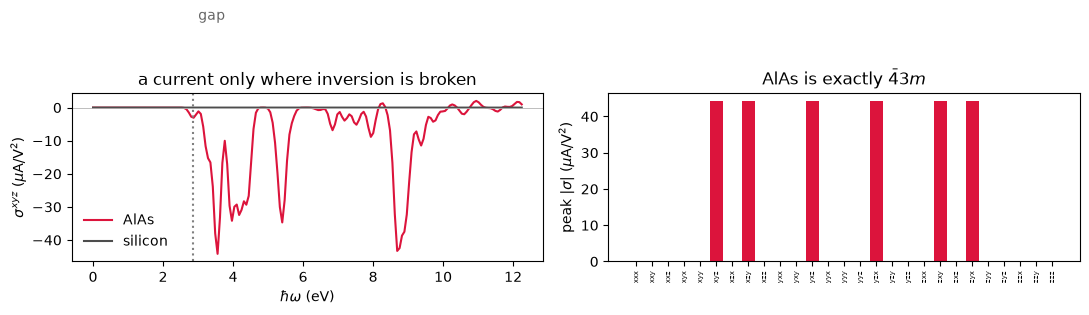

In [3]:
import matplotlib.pyplot as plt

silicon = Calculator.from_file(CASES / "si2-nosym.in", PSEUDO, announce=False)
si_sigma = silicon.get_shift_current(nbnd=14, window=0.9, nw=180)

bands = alas.get_nscf(nbnd=8).eigenvalues
direct = float(np.min(bands[:, 4] - bands[:, 3])) * RY_TO_EV

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8))
a.plot(sigma.frequencies_ev, sigma.component(0, 1, 2) * 1e6, color="crimson", label="AlAs")
a.plot(si_sigma.frequencies_ev, si_sigma.component(0, 1, 2) * 1e6, color="0.3",
       label="silicon")
a.axvline(direct, ls=":", color="0.5")
a.text(direct + 0.15, 0.6 * peak * 1e6, "gap", color="0.4")
a.axhline(0, lw=0.6, color="0.7")
a.set(xlabel=r"$\hbar\omega$ (eV)", ylabel=r"$\sigma^{xyz}$ ($\mu$A/V$^2$)",
      title="a current only where inversion is broken")
a.legend(frameon=False)

for name, value in entries.items():
    b.bar(name, value * 1e6, color="crimson" if len(set(name)) == 3 else "0.75")
b.set(ylabel=r"peak $|\sigma|$ ($\mu$A/V$^2$)", title=r"AlAs is exactly $\bar{4}3m$")
b.tick_params(axis="x", labelrotation=90, labelsize=5)
fig.tight_layout()

Silicon's line sits on zero across the whole range, and AlAs's is zero too until the photon
can make a pair. Below the gap there is no absorption, so there is no carrier to displace
and no current: the effect is not a polarization response but a *transport* one, and it
switches on with the joint density of states.

## What the sign means, and why this is not an ordinary photocurrent

The shift current is real and instantaneous rather than resistive. Its size is set by the
absorption strength multiplied by a **length**: how far the charge centre moves when an
electron is promoted from the valence band to the conduction band at that wavevector. That
length is a property of the wavefunctions and not of the energies, which is why two
materials with the same band structure and the same absorption spectrum can have shift
currents differing by an order of magnitude, and why the sign can reverse within a single
absorption peak.

It also explains the material trend. The displacement is largest where the valence and
conduction states are centred on *different* atoms, so the response grows with the
ionicity and with how delocalised the excited state is. Among the zincblende
semiconductors the aluminium compounds respond most strongly, and the II-VI ones least.

In [4]:
below = sigma.frequencies_ev < 6.0
first = np.abs(sigma.component(0, 1, 2)[below]).max()

print("%-40s %s" % ("", "peak, uA/V^2"))
print("%-40s %8.0f" % ("AlSb, largest of the family", 83))
print("%-40s %8.0f" % ("AlAs, converged, quoted", 35))
print("%-40s %8.1f" % ("AlAs, this cell", first * 1e6))
print("%-40s %8.0f" % ("CdSe, smallest of the family", 14))
print("%-40s %8.0f" % ("silicon, this cell", 0))

                                         peak, uA/V^2
AlSb, largest of the family                    83
AlAs, converged, quoted                        35
AlAs, this cell                              44.2
CdSe, smallest of the family                   14
silicon, this cell                              0


The cell this notebook runs on is small, so its own number is high by about a quarter.
Repeating it at a larger basis converges the first peak to **35 $\mu$A/V$^2$ at 4.2 eV**,
to about one per cent in both the cutoff and the number of bands, and that is the number
to compare against published work.

It sits inside the range those calculations find across the fourteen III-V and II-VI
zincblende semiconductors, and the *ordering* is the part that carries information. They
find the aluminium compounds to be the strongest responders of the family and the II-VI
compounds the weakest, so AlAs belongs above the middle of a band running from 14 to 83.
Thirty-five is where that puts it. Half of it would put AlAs at the very bottom, below the
cadmium chalcogenides, and twice it would put AlAs beside AlSb, the heaviest and
narrowest-gap member of the family. So the comparison is sharp enough to fix the overall
scale even though no measured value for AlAs exists to check against, and even though a
peak height depends on the gap: what a calculation of this kind reproduces is the
magnitude and the trend rather than a digit.

The comparison is made below 6 eV, which is the range published spectra cover. There is
more structure above it, and at the band count used here that is the part least worth
trusting.

**The convention differs between papers by a factor of two**, and it is the thing to check
before quoting a shift current from anywhere, this notebook included. The definition at
the top, with the explicit 2, is the one used in most first-principles work; some authors
write $J = \sigma \mathcal{E}\mathcal{E}$ and report numbers twice as large for the same
physics. The comparison above is against the first convention.

The response is also a sum over *pairs* of bands with a virtual state summed between them,
so it converges slowly in the number of empty states kept. The result carries that as a
diagnostic, and it is the first thing to read before believing a magnitude.

In [5]:
print("bands used: %d      truncation diagnostic: %.1f%%"
      % (sigma.nbnd, 100 * sigma.truncation))

bands used: 14      truncation diagnostic: 4.5%


At the small basis this cell runs in, a few per cent. It falls as the band set grows and
reaches the fourth decimal only when the states span the space, which is the honest cost
of computing this quantity without an interpolated Wannier basis.

---

**What this notebook computed.** The shift-current tensor of AlAs and of silicon,
the crystal class falling out of the zone sum with nothing imposing it, and the
absorption edge below which no current flows.

**Where to look next.** `28_piezoelectricity` computes the other polar rank-3 tensor of
the same crystal, and `27_excitons_and_tddft` computes the absorption that this current
rides on. Quantum ESPRESSO and Elk both compute neither this quantity nor any other
photocurrent.

**What it refuses**: ultrasoft and PAW datasets, metals, spin spirals, collinear spin,
DFT+U, and a symmetry-reduced k-point set. The validation that stands behind it lives in
`tests/regression/test_photocurrent.py`.